#**Spam Email Detection Project**

In [1]:
from google.colab import files
import pandas as pd

# Upload the CSV file from your computer
uploaded = files.upload()


Saving mail_data.csv to mail_data.csv


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/mail_data.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display information about the DataFrame
print("\nDataFrame Info:")
df.info()

# Check for any missing values
print("\nMissing values in each column:")
display(df.isnull().sum())

First 5 rows of the dataset:


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing values in each column:


,0
Category,0
Message,0


### Data Preprocessing

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# 1. Label Encoding for 'Category' column
encoder = LabelEncoder()
df['Category_Encoded'] = encoder.fit_transform(df['Category'])

print("Original Categories:", df['Category'].unique())
print("Encoded Categories:", df['Category_Encoded'].unique())

# 2. Text Vectorization using TF-IDF
# This converts the text messages into numerical feature vectors
tfidf_vectorizer = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)

X = tfidf_vectorizer.fit_transform(df['Message']).toarray()
y = df['Category_Encoded'].values

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (labels): {y.shape}")

Original Categories: ['ham' 'spam']
Encoded Categories: [0 1]
Shape of X (features): (5572, 8440)
Shape of y (labels): (5572,)


### Exploratory Data Analysis (EDA)

Distribution of Categories:


,count
Category,
ham,4825
spam,747


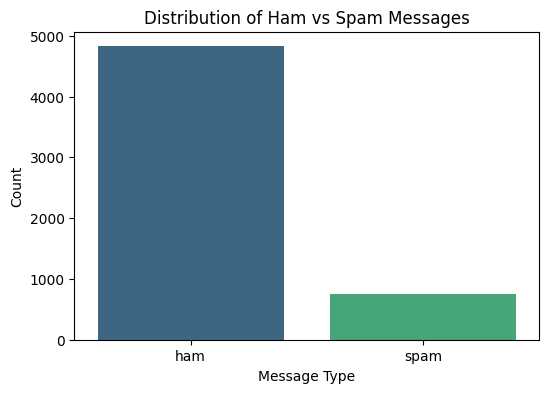

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of 'ham' vs 'spam' messages
print("Distribution of Categories:")
display(df['Category'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Category', hue='Category', data=df, palette='viridis', legend=False)
plt.title('Distribution of Ham vs Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

### Message Length Analysis

First 5 rows with Message Length:


,Category,Message,Category_Encoded,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,ham,U dun say so early hor... U c already then say...,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61


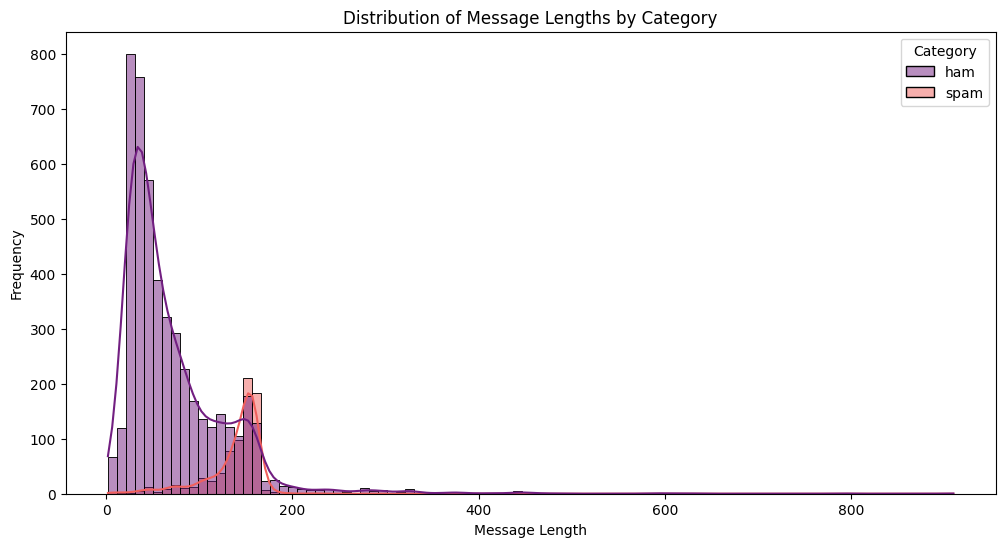


Statistical Summary of Message Lengths by Category:


,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
ham,4825.0,71.44829,58.434864,2.0,33.0,52.0,93.0,910.0
spam,747.0,137.98929,29.980287,7.0,132.0,149.0,157.0,223.0


In [5]:
# Add a new column for message length
df['Message_Length'] = df['Message'].apply(len)

print("First 5 rows with Message Length:")
display(df.head())

# Visualize the distribution of message lengths
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Message_Length', hue='Category', kde=True, palette='magma')
plt.title('Distribution of Message Lengths by Category')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()

# Statistical summary of message lengths
print("\nStatistical Summary of Message Lengths by Category:")
display(df.groupby('Category')['Message_Length'].describe())

### Splitting the Data into Training and Testing Sets

In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4457, 8440)
X_test shape: (1115, 8440)
y_train shape: (4457,)
y_test shape: (1115,)


### Model Training and Evaluation

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize and Train the Logistic Regression Model
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)

print("Model training complete.\n")

# 2. Make predictions on the test data
y_pred = model.predict(X_test)


# 3. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Model training complete.

Accuracy Score: 0.9570

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       966
           1       1.00      0.68      0.81       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



###Comparison of Actual vs. Predicted Categories

In [8]:
# Ensure encoder is defined from cell c2723fd0
# Ensure y_test and y_pred are defined from cell 186aa600

import pandas as pd

# Inverse transform numerical labels back to 'ham' and 'spam'
actual_labels = encoder.inverse_transform(y_test)
predicted_labels = encoder.inverse_transform(y_pred)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual Category': actual_labels,
    'Predicted Category': predicted_labels
})

print("Comparison of Actual vs. Predicted Categories:")
display(comparison_df.head(20)) # Display first 20 for brevity

Comparison of Actual vs. Predicted Categories:


,Actual Category,Predicted Category
0,ham,ham
1,ham,ham
2,ham,ham
3,ham,ham
4,ham,ham
5,ham,ham
6,ham,ham
7,ham,ham
8,ham,ham
9,ham,ham


<Figure size 800x600 with 0 Axes>

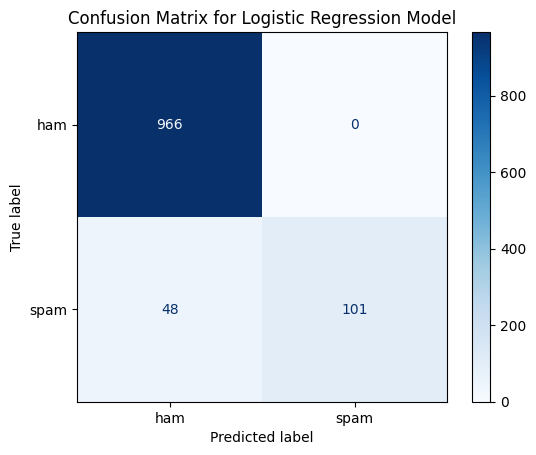

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ensure y_test and y_pred are defined from cell 186aa600
# Ensure encoder is defined from cell c2723fd0

# Get the class names ('ham', 'spam') from the encoder
class_names = encoder.classes_

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()